# Point Clouds — Load ▸ Clean ▸ Visualize ▸ Animate
**with PyVista (VTK-powered)**  
**Last updated:** 2025-11-09

This beginner-friendly tutorial covers:
1) Loading or generating point clouds  
2) Basic visualization (colors, size, scalars)  
3) Cleaning: NaN removal, voxel-grid downsampling, simple outlier removal  
4) Normal estimation (PCA on neighbors)  
5) Saving PLY with colors/normals  
6) Multi-view comparisons  
7) Simple camera animation → MP4


## 0. Setup
If you don’t have the packages yet, install these:

```bash
pip install pyvista imageio-ffmpeg numpy scipy
```
PyVista uses `imageio-ffmpeg` (or your system FFmpeg) to write MP4.

In [1]:
import numpy as np
from IPython.display import Image, display

try:
    import pyvista as pv
except Exception as e:
    pv = None
    print('PyVista not available:', e)

try:
    from scipy.spatial import cKDTree
except Exception:
    cKDTree = None

print('PyVista version:', getattr(pv, '__version__', 'not found'))


PyVista version: 0.46.4


## 1. Create or load a point cloud
We’ll synthesize a noisy sphere cloud so this runs anywhere. Replace with your own PLY/OBJ/VTK via `pv.read('file.ply')`.

In [2]:
rng = np.random.default_rng(0)
n = 20000
phi = rng.uniform(0, 2*np.pi, n)
costh = rng.uniform(-1, 1, n)
sinth = np.sqrt(1 - costh**2)
x = sinth * np.cos(phi)
y = sinth * np.sin(phi)
z = costh
pts = np.vstack([x, y, z]).T
pts += rng.normal(scale=0.01, size=pts.shape)

colors = (rng.uniform(0.2, 1.0, size=(n,3)) * 255).astype(np.uint8)
cloud = pv.PolyData(pts)
cloud['RGB'] = colors
cloud


PolyData (0x7517386a2140)
  N Cells:    20000
  N Points:   20000
  N Strips:   0
  X Bounds:   -1.017e+00, 1.030e+00
  Y Bounds:   -1.017e+00, 1.021e+00
  Z Bounds:   -1.017e+00, 1.023e+00
  N Arrays:   1

## 2. Visualize the point cloud
- Control **point size**, **opacity**, **background**, **camera**.  
- If your file has colors (RGB), pass `scalars='RGB'` with `rgb=True`.  
- Save a PNG screenshot (off-screen).

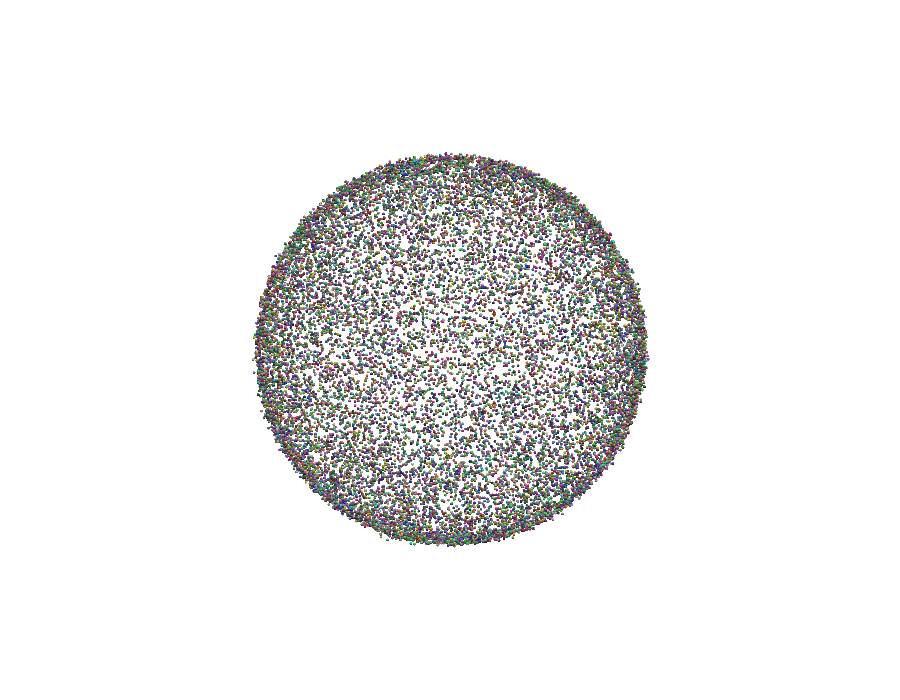

In [26]:
pl = pv.Plotter(off_screen=True, window_size=(900, 700))
pl.set_background('white')
pl.add_points(cloud, scalars='RGB', rgb=True, point_size=3.0, render_points_as_spheres=True)
pl.camera_position = 'iso'
png = 'pc_basic.png'
pl.show(screenshot=png, jupyter_backend="static")


## 3. Clean the cloud
### 3.1 Drop NaNs/duplicates
### 3.2 Voxel-grid downsampling
Downsampling speeds up rendering/processing by snapping points to a 3D grid and keeping one point per voxel.

In [4]:
def drop_nans_dupes(points, colors=None):
    ok = np.isfinite(points).all(axis=1)
    points = points[ok]
    if colors is not None:
        colors = colors[ok]
    key = np.round(points, 9)
    _, idx = np.unique(key, axis=0, return_index=True)
    points = points[idx]
    colors = colors[idx] if colors is not None else None
    return points, colors

def voxel_downsample(points, voxel_size, colors=None):
    if voxel_size <= 0:
        return points, colors
    mins = points.min(axis=0)
    vids = np.floor((points - mins) / voxel_size).astype(np.int64)
    _, idx = np.unique(vids, axis=0, return_index=True)
    pts_ds = points[idx]
    cols_ds = colors[idx] if colors is not None else None
    return pts_ds, cols_ds


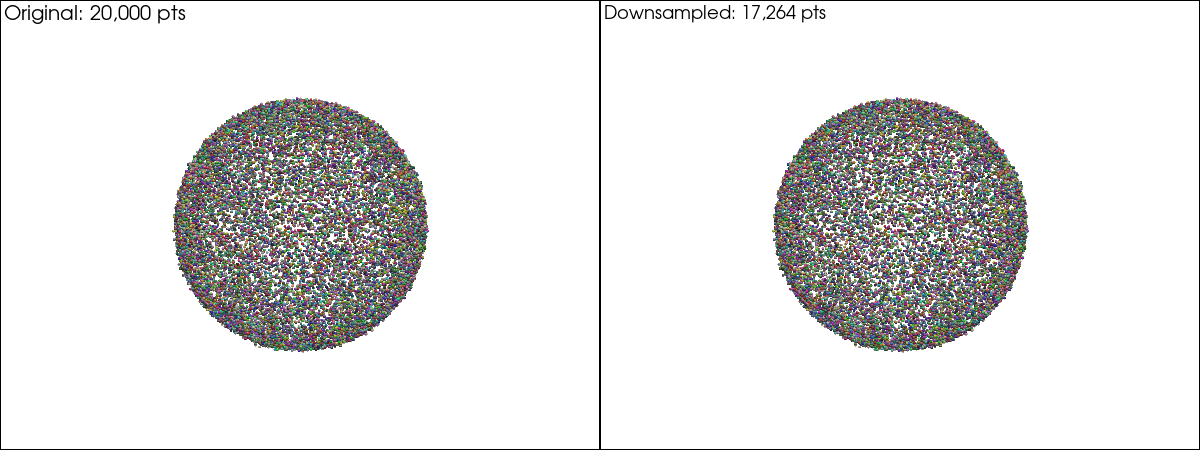

In [27]:
pts = cloud.points.copy()
cols = cloud['RGB'].copy()
pts, cols = drop_nans_dupes(pts, cols)
pts_ds, cols_ds = voxel_downsample(pts, voxel_size=0.02, colors=cols)
cloud_ds = pv.PolyData(pts_ds)
if cols_ds is not None:
    cloud_ds['RGB'] = cols_ds

plotter = pv.Plotter(shape=(1,2), off_screen=True, window_size=(1200, 450))
plotter.subplot(0,0)
plotter.set_background('white')
plotter.add_points(pv.PolyData(pts), scalars=cols, rgb=True, point_size=3.0, render_points_as_spheres=True)
plotter.add_text(f'Original: {pts.shape[0]:,} pts', font_size=10)
plotter.subplot(0,1)
plotter.set_background('white')
plotter.add_points(cloud_ds, scalars='RGB', rgb=True, point_size=3.0, render_points_as_spheres=True)
plotter.add_text(f'Downsampled: {pts_ds.shape[0]:,} pts', font_size=10)
plotter.link_views()
png = 'pc_downsample_compare.png'
plotter.show(screenshot=png, jupyter_backend="static")


### 3.3 Simple outlier removal
Remove isolated points using a **radius** or **kNN** rule. We use a radius-count with `cKDTree` when available.

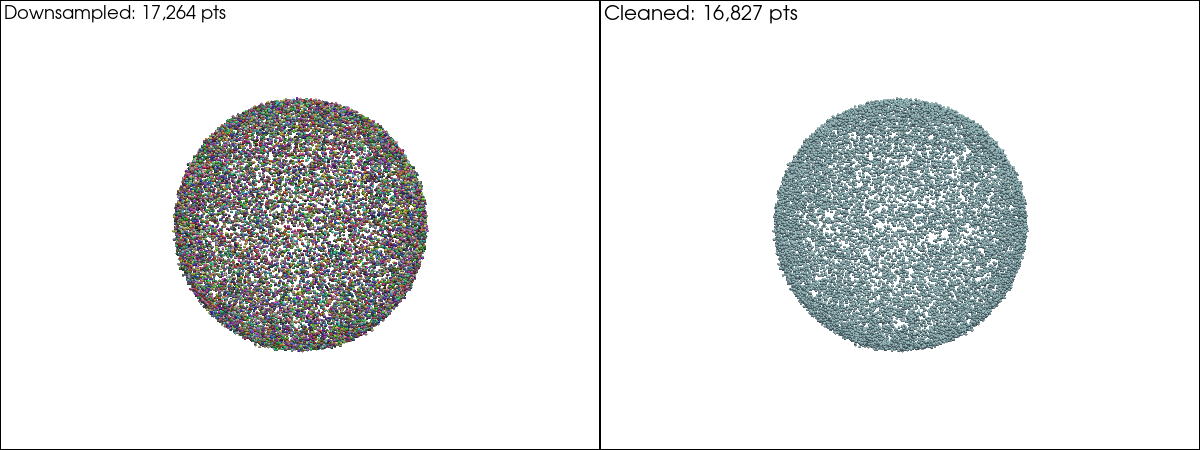

In [25]:
def radius_outlier_removal(points, r=0.05, min_neighbors=6):
    if cKDTree is None:
        print('cKDTree not available; skipping outlier removal.')
        return points
    tree = cKDTree(points)
    counts = tree.query_ball_point(points, r, return_length=True)
    keep = counts >= min_neighbors
    return points[keep]

pts_clean = radius_outlier_removal(pts_ds, r=0.05, min_neighbors=6)
color_ok = None
if pts_clean.shape[0] == pts_ds.shape[0]:
    color_ok = cols_ds
cloud_clean = pv.PolyData(pts_clean)
if color_ok is not None:
    cloud_clean['RGB'] = color_ok

pl = pv.Plotter(shape=(1,2), off_screen=True, window_size=(1200, 450))
pl.subplot(0,0); pl.set_background('white')
pl.add_points(cloud_ds, scalars='RGB' if 'RGB' in cloud_ds.array_names else None,
              rgb='RGB' in cloud_ds.array_names, point_size=3.0, render_points_as_spheres=True)
pl.add_text(f'Downsampled: {pts_ds.shape[0]:,} pts', font_size=10)
pl.subplot(0,1); pl.set_background('white')
pl.add_points(cloud_clean, scalars='RGB' if 'RGB' in cloud_clean.array_names else None,
              rgb='RGB' in cloud_clean.array_names, point_size=3.0, render_points_as_spheres=True)
pl.add_text(f'Cleaned: {pts_clean.shape[0]:,} pts', font_size=10)
pl.link_views()
png = 'pc_outlier_compare.png'
pl.show(screenshot=png, jupyter_backend="static")


## 4. Estimate normals (PCA on neighbors)
For each point, take its **k nearest neighbors**, compute the **covariance** and the **smallest-eigenvalue eigenvector** → normal. Flip normals to face the camera (roughly) using a viewpoint.

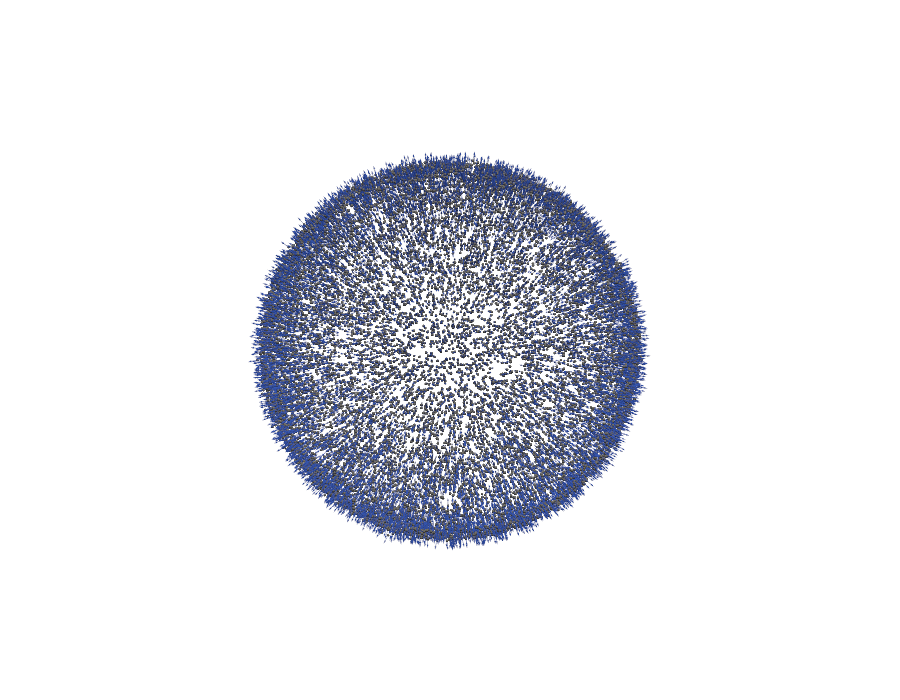

In [24]:
def estimate_normals_pca(points, k=16, viewpoint=(3,3,3)):
    if cKDTree is None:
        print('cKDTree not available; returning zeros for normals.')
        return np.zeros_like(points)
    tree = cKDTree(points)
    _, idxs = tree.query(points, k=k)
    normals = np.zeros_like(points)
    for i, nn in enumerate(idxs):
        P = points[nn]
        C = np.cov(P.T)
        w, v = np.linalg.eigh(C)
        n = v[:, np.argmin(w)]
        if np.dot(n, (np.asarray(viewpoint) - points[i])) < 0:
            n = -n
        normals[i] = n
    return normals

pts_for_normals = pts_clean if 'pts_clean' in locals() else pts_ds
normals = estimate_normals_pca(pts_for_normals, k=16)
cloud_n = pv.PolyData(pts_for_normals)
cloud_n['Normals'] = normals
glyphs = cloud_n.glyph(orient='Normals', scale=False, factor=0.05)
pl = pv.Plotter(off_screen=True, window_size=(900, 700))
pl.set_background('white')
pl.add_points(cloud_n, color='gray', point_size=3.0, render_points_as_spheres=True)
pl.add_mesh(glyphs, color='royalblue')
pl.camera_position = 'iso'
png = 'pc_normals.png'
pl.show(screenshot=png, jupyter_backend="static")


## 5. Save to PLY (with colors/normals)
**PLY** supports per-vertex RGB and normals. If you only have positions, that’s fine too.

In [9]:
save_cloud = cloud_n if 'cloud_n' in locals() else cloud_ds
save_path = 'pointcloud_saved.ply'
save_cloud.save(save_path)
print('Saved:', save_path)


Saved: pointcloud_saved.ply


2025-11-09 02:59:07.788 ( 141.390s) [    7517E6695600]       vtkPLYWriter.cxx:433   WARN| vtkPLYWriter (0x5d2a54f9a5a0): PLY writer only supports float normal vectors


## 6. Multi-view comparisons
Show **original vs downsampled vs cleaned** side-by-side.

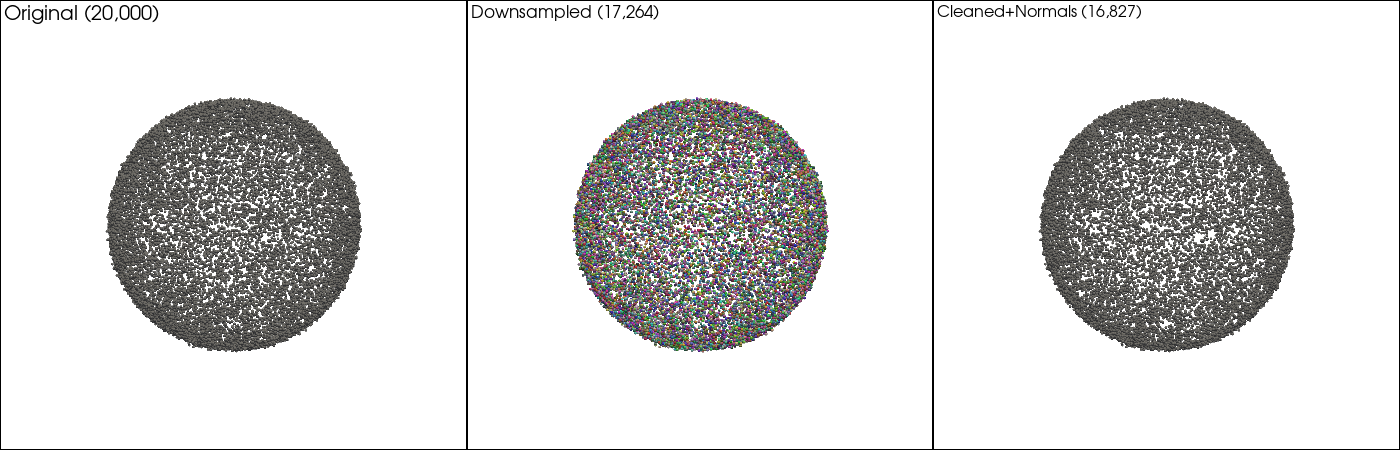

In [23]:
plotter = pv.Plotter(shape=(1,3), off_screen=True, window_size=(1400, 450))
for i, (obj, title) in enumerate([
    (pv.PolyData(pts), f'Original ({pts.shape[0]:,})'),
    (cloud_ds,        f'Downsampled ({pts_ds.shape[0]:,})'),
    (cloud_n,         f'Cleaned+Normals ({cloud_n.n_points:,})')
]):
    plotter.subplot(0,i)
    plotter.set_background('white')
    if 'RGB' in obj.array_names:
        plotter.add_points(obj, scalars='RGB', rgb=True, point_size=3.0, render_points_as_spheres=True)
    else:
        plotter.add_points(obj, color='gray', point_size=3.0, render_points_as_spheres=True)
    plotter.add_text(title, font_size=10)
    plotter.camera_position = 'iso'
plotter.link_views()
png = 'pc_multiview.png'
plotter.show(screenshot=png, jupyter_backend="static")


## 7. Simple camera orbit → MP4
Rotate the camera around the cloud and save an **MP4**.

In [15]:
obj = cloud_n if 'cloud_n' in locals() else cloud_ds
pl = pv.Plotter(off_screen=True, window_size=(900, 700))
pl.set_background('white')
if 'RGB' in obj.array_names:
    pl.add_points(obj, scalars='RGB', rgb=True, point_size=3.0, render_points_as_spheres=True)
else:
    pl.add_points(obj, color='gray', point_size=3.0, render_points_as_spheres=True)
pl.camera_position = 'iso'

mp4 = 'pointcloud_turntable.mp4'
try:
    pl.open_movie(mp4, framerate=30)
    pl.show(auto_close=False)
    for i in range(180):
        pl.camera.azimuth += 2.0
        pl.write_frame()
    pl.close()
    print('Saved MP4:', mp4)
except Exception as e:
    print('Movie failed:', e)

from IPython.display import Video
Video(mp4)

Widget(value='<iframe src="http://localhost:41199/index.html?ui=P_0x75171a664380_7&reconnect=auto" class="pyvi…

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (900, 700) to (912, 704) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved MP4: pointcloud_turntable.mp4


## 8. Tips & notes
- Keep a copy of the **original** point cloud; use downsampled copies for interactive work.
- Outlier removal parameters depend on **units** and **density**; adjust `r` and `min_neighbors`.
- Normal estimation is local; larger `k` smooths normals but may lose detail.
- For **registration** (aligning two clouds), look up `vtkIterativeClosestPointTransform`.
- For surface reconstruction, see VTK’s `vtkSurfaceReconstructionFilter` or try Poisson in other libraries.

## 9. Surface reconstruction from point clouds
We’ll turn a (reasonably uniform) point cloud into a **watertight surface mesh**.

Two classic approaches:
1) **VTK SurfaceReconstruction (Hoppe)**: estimate an implicit surface from oriented points → extract an isosurface.
2) **Poisson reconstruction** (if available in your VTK): robust watertight surfaces, prefers **oriented normals**.

**Tips**
- Downsample overly dense clouds first (voxel grid).
- For Poisson, good normals are important; use the normals we estimated above (or increase `k`).
- Reconstructions can fill holes and smooth fine details; tune parameters and compare results.

In [16]:
import numpy as np
from IPython.display import Image, display

try:
    src = cloud_n  # has normals
except NameError:
    try:
        src = cloud_ds
    except NameError:
        src = cloud  # fallback

# Optionally sub-sample to ~10k points for speed
max_pts = 12000
if src.n_points > max_pts:
    idx = np.random.default_rng(0).choice(src.n_points, size=max_pts, replace=False)
    src_sub = src.extract_points(idx, include_cells=False)
else:
    src_sub = src.copy(deep=True)

print('Reconstruction input points:', src_sub.n_points)


Reconstruction input points: 12000


### 9.1 VTK SurfaceReconstruction (Hoppe et al.)
Pipeline: `vtkSurfaceReconstructionFilter` → `vtkContourFilter` → (optional) `vtkReverseSense`.
This often works best on **uniformly sampled** point sets.

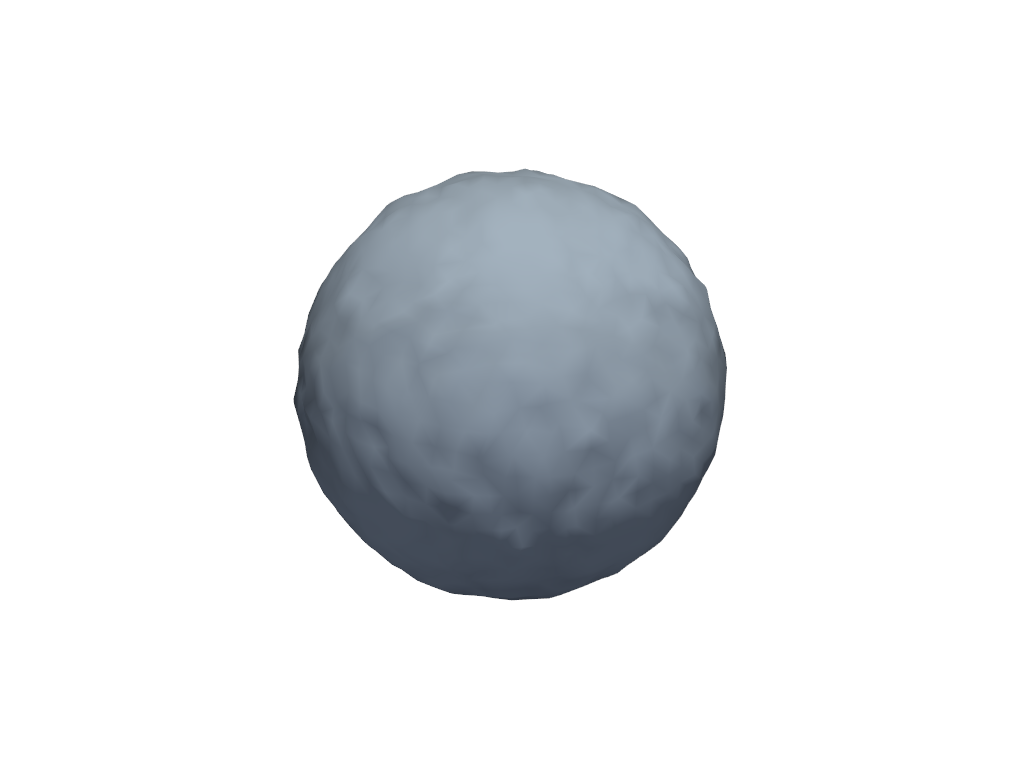

Saved Hoppe reconstruction → recon_hoppe.ply


In [22]:
# Ensure we have a PolyData with only points
points_only = pv.PolyData(src_sub.points)

# Wrap VTK filters via PyVista's .cast_to_unstructured_grid when needed
vtk_points = points_only

# Run VTK SurfaceReconstruction
import vtk
surf_recon = vtk.vtkSurfaceReconstructionFilter()
surf_recon.SetInputData(vtk_points)
# Parameter to tune smoothness/detail (default ok). For larger clouds, you can adjust sample spacing.
surf_recon.Update()

# Extract an isosurface from the implicit representation
cf = vtk.vtkContourFilter()
cf.SetInputConnection(surf_recon.GetOutputPort())
cf.SetValue(0, 0.0)  # iso-value 0 for the zero level set
cf.Update()

# The orientation may be flipped; reverse if needed
rev = vtk.vtkReverseSense()
rev.SetInputConnection(cf.GetOutputPort())
rev.ReverseCellsOn()
rev.ReverseNormalsOn()
rev.Update()

hoppe_mesh = pv.wrap(rev.GetOutput())
hoppe_mesh = hoppe_mesh.triangulate()

# Clean and smooth lightly
hoppe_mesh = hoppe_mesh.clean().smooth(n_iter=20, relaxation_factor=0.01)

# Preview & export
pl = pv.Plotter(off_screen=True)
pl.set_background('white')
pl.add_mesh(hoppe_mesh, color='lightsteelblue', smooth_shading=True)
pl.camera_position = 'iso'
png = 'recon_hoppe.png'
pl.show(screenshot=png, jupyter_backend="static")

hoppe_mesh.save('recon_hoppe.ply')
print('Saved Hoppe reconstruction → recon_hoppe.ply')


**Notes & troubleshooting**
- For **noisy/irregular** clouds, downsample and/or apply outlier removal before reconstruction.
- Increase `k` in normal estimation for smoother normals (helps Poisson), but may blur sharp features.
- Poisson depth controls detail and runtime; try 8–11.
- If normals point inconsistently, try re-orienting with `compute_normals(..., auto_orient_normals=True)` or flip using a viewpoint heuristic.
- Reconstructed meshes can be large. Consider decimation afterwards.